In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

QiskitRuntimeService.save_account(
    token="QPIl2rvgomW_N1LcftivJzDadXNeM9Q4UhtyRxucMbTV", # Your token is confidential.
    # Do not share your key in public code.
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/22dc8fdbcf474c5c8b2faee4cf250adb:6907401c-f66b-4337-8c3f-807e8f1947c4::", # Optionally specify the instance to use.
    name="maria", # Optionally name this set of account credentials.
    set_as_default=True, # Optionally set these as your default credentials.
    overwrite=True   
)

service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")

In [2]:
# Define parameters for the simulated backend
num_qubits = 20
shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20

# Set up the experiment object
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2, seed=SEED
)

# Set run options
exp.set_run_options(shots=shots)

# Run the experiment with timing
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)

Job IDs: ['d4eul40lslhc73cv4q7g']


In [3]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
analysis = exp.analysis.run(rb_data)

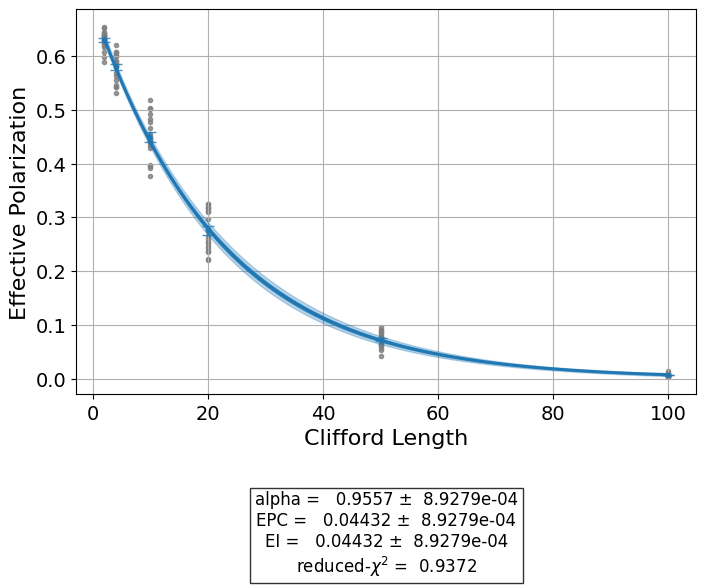

In [7]:
analysis.figure(0)

In [5]:
import os
import json
import qiskit
import qiskit.qasm2

# Get the job id
job_id = rb_data.job_ids[0]

# Create a folder with the job id as name
os.makedirs(job_id, exist_ok=True)

# Save qubit number
with open(f'{job_id}/{job_id}_qubits.json', 'w') as f:
    json.dump({"num_qubits": num_qubits}, f)

# Save pairs
with open(f'{job_id}_pairs.json', 'w') as f:
    json.dump(exp._pairs, f)

# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(job_id, f'circuit_{i}.json'), 'w') as f:
        qiskit.qasm2.dump(circ, f)



# Save the density
with open(f'{job_id}/{job_id}_density.json', 'w') as f:
    json.dump({"two_qubit_gate_density": exp.experiment_options.two_qubit_gate_density}, f)

# Save the seed
with open(f'{job_id}/{job_id}_seed.json', 'w') as f:
    json.dump({"seed": SEED}, f)

In [8]:
# Save the MRB plot (extract matplotlib figure from FigureData)
fig = analysis.figure(0).figure
fig.savefig(f'{job_id}/{job_id}_mrb_plot.png', dpi=300, bbox_inches='tight')

In [6]:
# count ops before transpilation
op_counts = exp.circuits()[2].count_ops()
print("Operation counts before transpilation:", op_counts)

# sum one qubit gates and two qubit gates separately
one_q_ops = 0
two_q_ops = 0
for op, count in op_counts.items():
    if op in ['x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'sx', 'sxdg']:
        one_q_ops += count
    elif op in ['cx', 'cz', 'swap', 'cy', 'ch', 'crz', 'cu1', 'cu3']:
        two_q_ops += count
print(f"One-qubit gates: {one_q_ops}, Two-qubit gates: {two_q_ops}")

# count ops after transpilation (experiment already finished)
op_counts_after = exp._static_trans_circuits[2].count_ops()
print("Operation counts after transpilation:", op_counts_after)
# sum one qubit gates and two qubit gates separately
one_q_ops_after = 0
two_q_ops_after = 0
for op, count in op_counts_after.items():
    if op in ['x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'sx', 'sxdg']:
        one_q_ops_after += count
    elif op in ['cx', 'cz', 'swap', 'cy', 'ch', 'crz', 'cu1', 'cu3']:
        two_q_ops_after += count
print(f"One-qubit gates after transpilation: {one_q_ops_after}, Two-qubit gates after transpilation: {two_q_ops_after}")

Operation counts before transpilation: OrderedDict({'rz': 138, 'sx': 98, 'Clifford-1Q(6)': 67, 'Clifford-1Q(0)': 66, 'Clifford-1Q(18)': 59, 'Clifford-1Q(12)': 46, 'cz': 46, 'barrier': 22, 'measure': 20, 'Clifford-1Q(3)': 9, 'Clifford-1Q(7)': 9, 'Clifford-1Q(5)': 9, 'Clifford-1Q(19)': 9, 'Clifford-1Q(15)': 8, 'Clifford-1Q(11)': 8, 'Clifford-1Q(13)': 6, 'Clifford-1Q(22)': 5, 'Clifford-1Q(4)': 5, 'Clifford-1Q(17)': 3, 'Clifford-1Q(21)': 3, 'Clifford-1Q(16)': 2, 'Clifford-1Q(9)': 2, 'Clifford-1Q(14)': 2, 'Clifford-1Q(10)': 2, 'Clifford-1Q(20)': 2, 'Clifford-1Q(1)': 2, 'Clifford-1Q(23)': 2, 'Clifford-1Q(8)': 1, 'Clifford-1Q(2)': 1})
One-qubit gates: 236, Two-qubit gates: 46
Operation counts after transpilation: OrderedDict({'rz': 381, 'sx': 174, 'x': 117, 'cz': 46, 'barrier': 22, 'measure': 20})
One-qubit gates after transpilation: 672, Two-qubit gates after transpilation: 46
